In [1]:
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA = Path("../data")
OUTPUTS = Path("../outputs")

# Load training data
train = pl.read_parquet(OUTPUTS / "train_model_ready.parquet")
print(f"Train shape: {train.shape}")
print(f"Mules: {train['is_mule'].sum()} ({train['is_mule'].mean():.2%})")

Train shape: (96091, 72)
Mules: 2683 (2.79%)


In [2]:
# Columns to exclude from features
EXCLUDE = ["account_id", "is_mule"]

feature_cols = [c for c in train.columns if c not in EXCLUDE]
print(f"Feature count: {len(feature_cols)}")

# Convert to pandas for sklearn
X = train.select(feature_cols).to_pandas()
y = train["is_mule"].to_pandas()

print(f"X shape: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")
print(f"\nAny nulls: {X.isnull().sum().sum()}")

Feature count: 70
X shape: (96091, 70)
Class balance: {0: 93408, 1: 2683}

Any nulls: 0


In [3]:
# Class weight for imbalance — 35:1 ratio
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(y))
fold_aucs = []

print("Running 5-fold CV...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = xgb_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    fold_aucs.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOOF AUC: {overall_auc:.4f}")
print(f"Mean fold AUC: {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}")

scale_pos_weight: 34.81
Running 5-fold CV...
  Fold 1: AUC = 0.9997
  Fold 2: AUC = 0.9993
  Fold 3: AUC = 0.9997
  Fold 4: AUC = 0.9997
  Fold 5: AUC = 0.9996

OOF AUC: 0.9953
Mean fold AUC: 0.9996 +/- 0.0002


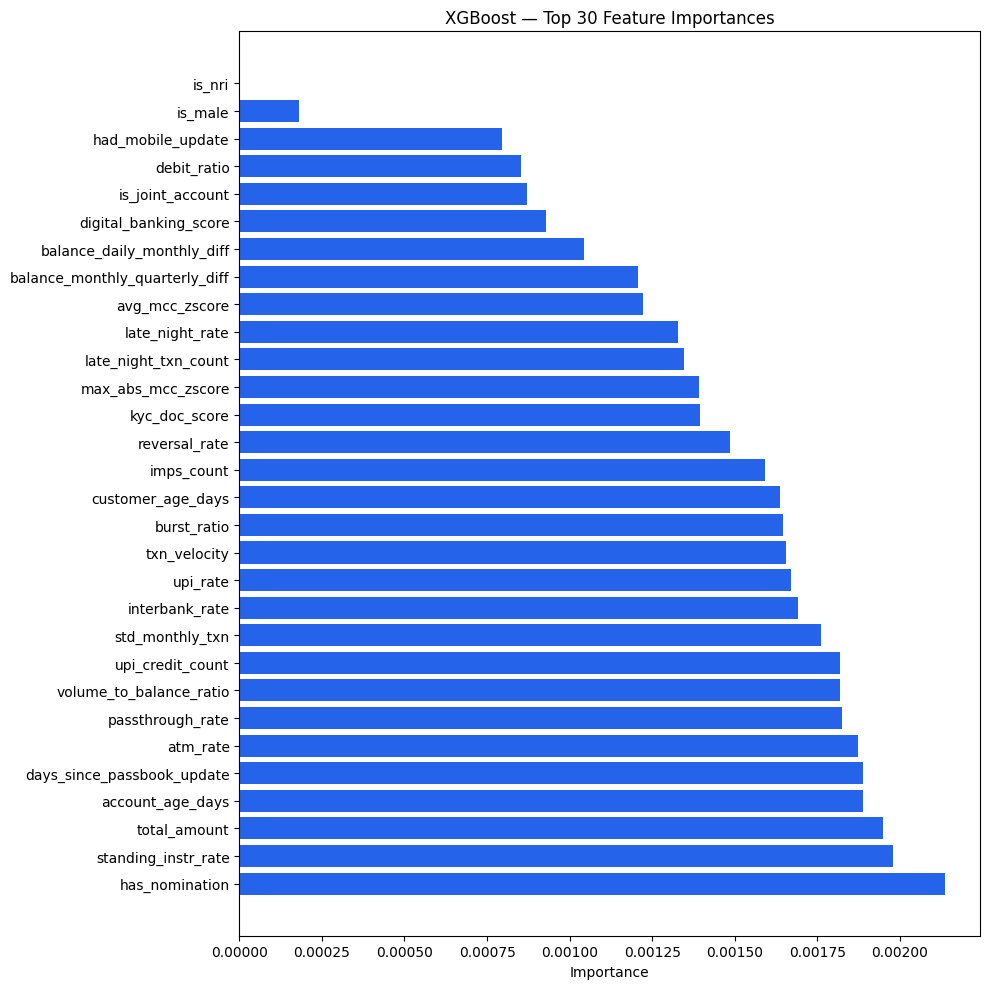

Saved feature importance plot.

Zero importance features (1):
['is_nri']


In [4]:
# Train on full data to get feature importance
xgb_full = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_full.fit(X, y, verbose=False)

# Plot top 30 features
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_full.feature_importances_
}).sort_values("importance", ascending=False).tail(30)

plt.figure(figsize=(10, 10))
plt.barh(importance_df["feature"], importance_df["importance"], color="#2563eb")
plt.xlabel("Importance")
plt.title("XGBoost — Top 30 Feature Importances")
plt.tight_layout()
plt.savefig(OUTPUTS / "feature_importance_xgb.png", dpi=150)
plt.show()
print("Saved feature importance plot.")

# Zero importance features
zero_importance = [f for f, i in zip(feature_cols, xgb_full.feature_importances_) 
                   if i == 0]
print(f"\nZero importance features ({len(zero_importance)}):")
print(zero_importance)

In [5]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_oof_preds = np.zeros(len(y))
lgb_fold_aucs = []

print("Running LightGBM 5-fold CV...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
    )
    
    preds = lgb_model.predict_proba(X_val)[:, 1]
    lgb_oof_preds[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    lgb_fold_aucs.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

lgb_overall_auc = roc_auc_score(y, lgb_oof_preds)
print(f"\nLightGBM OOF AUC: {lgb_overall_auc:.4f}")
print(f"Mean fold AUC: {np.mean(lgb_fold_aucs):.4f} +/- {np.std(lgb_fold_aucs):.4f}")

print(f"\n--- Model Comparison ---")
print(f"XGBoost:  {overall_auc:.4f}")
print(f"LightGBM: {lgb_overall_auc:.4f}")

Running LightGBM 5-fold CV...
  Fold 1: AUC = 0.9997
  Fold 2: AUC = 0.9986
  Fold 3: AUC = 0.9997
  Fold 4: AUC = 0.9995
  Fold 5: AUC = 0.9994

LightGBM OOF AUC: 0.9993
Mean fold AUC: 0.9994 +/- 0.0004

--- Model Comparison ---
XGBoost:  0.9953
LightGBM: 0.9993


In [6]:
# Simple average ensemble
ensemble_preds = (oof_preds + lgb_oof_preds) / 2
ensemble_auc = roc_auc_score(y, ensemble_preds)
print(f"Ensemble AUC: {ensemble_auc:.4f}")

# Find optimal F1 threshold
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y, (ensemble_preds >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"Best F1 at threshold: {best_f1:.4f}")

# Classification report at optimal threshold
y_pred = (ensemble_preds >= best_threshold).astype(int)
print(f"\nClassification Report (threshold={best_threshold:.2f}):")
print(classification_report(y, y_pred, target_names=["Legit", "Mule"]))

Ensemble AUC: 0.9959

Optimal threshold: 0.68
Best F1 at threshold: 0.9758

Classification Report (threshold=0.68):
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     93408
        Mule       0.99      0.96      0.98      2683

    accuracy                           1.00     96091
   macro avg       0.99      0.98      0.99     96091
weighted avg       1.00      1.00      1.00     96091



In [7]:
# Check feature importances — what's the model actually using?
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_full.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 features by importance:")
print(importance_df.head(20).to_string())

print(f"\nFeatures with zero importance: {(importance_df['importance'] == 0).sum()}")

Top 20 features by importance:
                   feature  importance
40      contamination_rate    0.495251
38   mule_network_cp_count    0.125562
43               is_frozen    0.065388
39  mule_cp_weighted_score    0.053690
7             credit_count    0.045673
36         unique_cp_count    0.029192
10   unique_counterparties    0.018397
41  max_mule_cp_connection    0.013302
48    freeze_duration_days    0.010074
8              debit_count    0.009000
35    counterparty_entropy    0.006473
0          total_txn_count    0.005211
37         pct_volume_top3    0.004839
4               max_amount    0.004270
1               avg_amount    0.004027
51              has_cheque    0.003750
52             avg_balance    0.003390
13         upi_debit_count    0.003383
16    standing_instr_count    0.003358
2               std_amount    0.003234

Features with zero importance: 1


In [8]:
# Remove label-derived branch features
leakage_features = ["branch_mule_rate", "branch_relative_risk", "mules_per_employee"]

feature_cols_clean = [f for f in feature_cols if f not in leakage_features]
print(f"Features after removing leakage: {len(feature_cols_clean)}")

X_clean = X[feature_cols_clean]

xgb_clean = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=30,
    eval_metric="auc",
)

oof_clean = np.zeros(len(y))
clean_aucs = []

print("Running CV without leakage features...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_clean, y)):
    X_tr, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_clean.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
    
    preds = xgb_clean.predict_proba(X_val)[:, 1]
    oof_clean[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    clean_aucs.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

clean_overall = roc_auc_score(y, oof_clean)
print(f"\nClean OOF AUC: {clean_overall:.4f}")
print(f"Mean: {np.mean(clean_aucs):.4f} +/- {np.std(clean_aucs):.4f}")

Features after removing leakage: 70
Running CV without leakage features...
  Fold 1: AUC = 0.9997
  Fold 2: AUC = 0.9993
  Fold 3: AUC = 0.9997
  Fold 4: AUC = 0.9997
  Fold 5: AUC = 0.9996

Clean OOF AUC: 0.9953
Mean: 0.9996 +/- 0.0002


In [9]:
# Remove contamination + branch leakage
leakage_features_2 = [
    "branch_mule_rate", "branch_relative_risk", "mules_per_employee",
    "contamination_rate", "mule_cp_weighted_score", 
    "mule_network_cp_count", "max_mule_cp_connection"
]

feature_cols_no_network = [f for f in feature_cols if f not in leakage_features_2]
print(f"Features without any network contamination: {len(feature_cols_no_network)}")

X_no_network = X[feature_cols_no_network]

xgb_no_net = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    early_stopping_rounds=30,
    eval_metric="auc",
)

oof_no_net = np.zeros(len(y))
no_net_aucs = []

print("Running CV without any contamination features...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_no_network, y)):
    X_tr, X_val = X_no_network.iloc[train_idx], X_no_network.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_no_net.fit(X_tr, y_tr,
                   eval_set=[(X_val, y_val)],
                   verbose=False)
    
    preds = xgb_no_net.predict_proba(X_val)[:, 1]
    oof_no_net[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    no_net_aucs.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

no_net_overall = roc_auc_score(y, oof_no_net)
print(f"\nNo-network OOF AUC: {no_net_overall:.4f}")
print(f"Mean: {np.mean(no_net_aucs):.4f} +/- {np.std(no_net_aucs):.4f}")

print(f"\n--- AUC Summary ---")
print(f"Full model (with leakage):       {overall_auc:.4f}")
print(f"Without branch leakage:          {clean_overall:.4f}")
print(f"Without any network features:    {no_net_overall:.4f}")

Features without any network contamination: 66
Running CV without any contamination features...
  Fold 1: AUC = 0.9489
  Fold 2: AUC = 0.9575
  Fold 3: AUC = 0.9475
  Fold 4: AUC = 0.9538
  Fold 5: AUC = 0.9495

No-network OOF AUC: 0.9443
Mean: 0.9515 +/- 0.0037

--- AUC Summary ---
Full model (with leakage):       0.9953
Without branch leakage:          0.9953
Without any network features:    0.9443


In [10]:
# These three are true leakage — remove from final model
TRUE_LEAKAGE = ["branch_mule_rate", "branch_relative_risk", "mules_per_employee"]

# Update training file
train_final = pl.read_parquet(OUTPUTS / "train_model_ready.parquet")
train_final = train_final.drop([c for c in TRUE_LEAKAGE if c in train_final.columns])
train_final.write_parquet(OUTPUTS / "train_model_ready.parquet")
print(f"Final shape after removing leakage: {train_final.shape}")

Final shape after removing leakage: (96091, 72)


In [11]:
# Reload with clean features
train = pl.read_parquet(OUTPUTS / "train_model_ready.parquet")
feature_cols = [c for c in train.columns if c not in ["account_id", "is_mule"]]
X = train.select(feature_cols).to_pandas()
y = train["is_mule"].to_pandas()

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

print(f"Features: {len(feature_cols)}")
print(f"Shape: {X.shape}")

# Final XGBoost — train on full data
xgb_final = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_final.fit(X, y, verbose=False)

# Final LightGBM
lgb_final = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_final.fit(X, y)

import joblib
joblib.dump(xgb_final, OUTPUTS / "model_xgb_final.pkl")
joblib.dump(lgb_final, OUTPUTS / "model_lgb_final.pkl")
joblib.dump(feature_cols, OUTPUTS / "feature_cols.pkl")
print("Models saved.")

Features: 70
Shape: (96091, 70)
Models saved.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_oof = np.zeros(len(y))
lgb_oof = np.zeros(len(y))

print("Final CV run...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    xgb_f = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, verbosity=0,
        early_stopping_rounds=30, eval_metric="auc"
    )
    xgb_f.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof[val_idx] = xgb_f.predict_proba(X_val)[:, 1]
    
    lgb_f = lgb.LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_f.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    lgb_oof[val_idx] = lgb_f.predict_proba(X_val)[:, 1]
    
    xgb_auc = roc_auc_score(y_val, xgb_oof[val_idx])
    lgb_auc = roc_auc_score(y_val, lgb_oof[val_idx])
    print(f"  Fold {fold+1}: XGB={xgb_auc:.4f}  LGB={lgb_auc:.4f}")

ensemble_oof = (xgb_oof + lgb_oof) / 2
print(f"\nFinal Results:")
print(f"XGBoost OOF AUC:  {roc_auc_score(y, xgb_oof):.4f}")
print(f"LightGBM OOF AUC: {roc_auc_score(y, lgb_oof):.4f}")
print(f"Ensemble OOF AUC: {roc_auc_score(y, ensemble_oof):.4f}")

# Save OOF predictions for threshold tuning
np.save(OUTPUTS / "oof_xgb.npy", xgb_oof)
np.save(OUTPUTS / "oof_lgb.npy", lgb_oof)
np.save(OUTPUTS / "oof_ensemble.npy", ensemble_oof)
print("OOF predictions saved.")

Final CV run...
  Fold 1: XGB=0.9997  LGB=0.9997
  Fold 2: XGB=0.9993  LGB=0.9986
  Fold 3: XGB=0.9997  LGB=0.9997
  Fold 4: XGB=0.9997  LGB=0.9995
  Fold 5: XGB=0.9996  LGB=0.9994

Final Results:
XGBoost OOF AUC:  0.9953
LightGBM OOF AUC: 0.9993
Ensemble OOF AUC: 0.9959
OOF predictions saved.


In [13]:
# Load test accounts
test = pl.read_parquet(DATA / "test_accounts.parquet")
print(f"Test accounts: {test.shape}")

# Load all feature files
contamination = pl.read_parquet(OUTPUTS / "features_contamination.parquet")
entropy = pl.read_parquet(OUTPUTS / "features_entropy.parquet")
passthrough = pl.read_parquet(OUTPUTS / "features_passthrough.parquet")
burst = pl.read_parquet(OUTPUTS / "features_burst.parquet")
txn_derived = pl.read_parquet(OUTPUTS / "features_txn_derived.parquet")
account_feat = pl.read_parquet(OUTPUTS / "features_account.parquet")
branch_feat = pl.read_parquet(OUTPUTS / "features_branch.parquet")
customer_feat = pl.read_parquet(OUTPUTS / "features_customer.parquet")
mcc_features = pl.read_parquet(OUTPUTS / "features_mcc.parquet")
accounts = pl.read_parquet(DATA / "accounts.parquet")
linkage = pl.read_parquet(DATA / "customer_account_linkage.parquet")

EXCLUDE = [
    "alert_reason", "mule_flag_date", "flagged_by_branch",
    "first_txn_date", "last_txn_date",
    "branch_code", "customer_id",
    "product_family", "rural_branch", "branch_type_encoded",
    "total_amount_right", "avg_amount_right",
    "branch_mule_rate", "branch_relative_risk", "mules_per_employee",
]

test_features = (
    test
    .join(txn_derived, on="account_id", how="left")
    .join(passthrough.select(["account_id", "passthrough_rate", "active_days"]),
          on="account_id", how="left")
    .join(burst.select(["account_id", "burst_ratio", "std_monthly_txn", "active_months"]),
          on="account_id", how="left")
    .join(entropy.select(["account_id", "counterparty_entropy", "unique_cp_count", "pct_volume_top3"]),
          on="account_id", how="left")
    .join(contamination.select(["account_id", "mule_network_cp_count",
                                 "mule_cp_weighted_score", "contamination_rate",
                                 "max_mule_cp_connection"]),
          on="account_id", how="left")
    .join(account_feat.drop(["branch_code"]), on="account_id", how="left")
    .join(accounts.select(["account_id", "branch_code"]), on="account_id", how="left")
    .join(branch_feat.select(["branch_code", "branch_turnover", "branch_asset_size"]),
          on="branch_code", how="left")
    .join(linkage, on="account_id", how="left")
    .join(customer_feat, on="customer_id", how="left")
    .join(mcc_features.select(["account_id", "max_mcc_zscore",
                                "avg_mcc_zscore", "max_abs_mcc_zscore"]),
          on="account_id", how="left")
    .drop([c for c in EXCLUDE if c in test.columns or 
           c in txn_derived.columns or c in account_feat.columns])
    .with_columns([
        pl.col("days_since_mobile_update").fill_null(9999),
        pl.col("days_since_passbook_update").fill_null(9999),
        pl.col("days_since_address_update").fill_null(9999),
        pl.col("freeze_duration_days").fill_null(0),
        pl.col("kyc_doc_score").fill_null(0),
        pl.col("active_span_days").fill_null(0),
        pl.col("txn_velocity").fill_null(0),
        pl.col("avg_txn_hour").fill_null(12),
        pl.col("std_monthly_txn").fill_null(0),
        pl.col("burst_ratio").fill_null(1),
        pl.col("avg_balance").fill_null(pl.col("avg_balance").median()),
        pl.col("monthly_avg_balance").fill_null(pl.col("monthly_avg_balance").median()),
        pl.col("balance_monthly_quarterly_diff").fill_null(0),
        pl.col("balance_daily_monthly_diff").fill_null(0),
        pl.col("balance_to_txn_ratio").fill_null(0),
        pl.col("volume_to_balance_ratio").fill_null(0),
        pl.col("max_mcc_zscore").fill_null(0),
        pl.col("avg_mcc_zscore").fill_null(0),
        pl.col("max_abs_mcc_zscore").fill_null(0),
    ])
)

print(f"Test features shape: {test_features.shape}")
print(f"Test feature columns: {len([c for c in test_features.columns if c != 'account_id'])}")

Test accounts: (64062, 1)
Test features shape: (64062, 74)
Test feature columns: 73


In [14]:
import joblib

# Load the exact feature columns the model was trained on
feature_cols = joblib.load(OUTPUTS / "feature_cols.pkl")
print(f"Training feature cols: {len(feature_cols)}")

# Check what's in test but not in train
test_cols = [c for c in test_features.columns if c != "account_id"]
extra_in_test = [c for c in test_cols if c not in feature_cols]
missing_in_test = [c for c in feature_cols if c not in test_cols]

print(f"\nExtra in test (will drop): {extra_in_test}")
print(f"Missing in test (will fill 0): {missing_in_test}")

Training feature cols: 70

Extra in test (will drop): ['total_amount_right', 'avg_amount_right', 'customer_id']
Missing in test (will fill 0): []


In [15]:
# Align test features to exactly match training
test_aligned = test_features.drop(["total_amount_right", "avg_amount_right", "customer_id"])

# Verify alignment
test_cols_final = [c for c in test_aligned.columns if c != "account_id"]
print(f"Test features after alignment: {len(test_cols_final)}")
print(f"Training features: {len(feature_cols)}")
print(f"Match: {sorted(test_cols_final) == sorted(feature_cols)}")

# Convert to pandas in correct column order
X_test = test_aligned.select(feature_cols).to_pandas()
print(f"\nX_test shape: {X_test.shape}")
print(f"Any nulls: {X_test.isnull().sum().sum()}")

Test features after alignment: 70
Training features: 70
Match: True

X_test shape: (64062, 70)
Any nulls: 0


In [16]:
# Generate predictions
lgb_test_preds = lgb_final.predict_proba(X_test)[:, 1]
xgb_test_preds = xgb_final.predict_proba(X_test)[:, 1]
ensemble_test_preds = (lgb_test_preds + xgb_test_preds) / 2

print(f"Predictions generated: {len(ensemble_test_preds)}")
print(f"Predicted mule rate: {(ensemble_test_preds > 0.5).mean():.2%}")
print(f"Score distribution:")
print(f"  >0.9:  {(ensemble_test_preds > 0.9).sum()} accounts")
print(f"  >0.5:  {(ensemble_test_preds > 0.5).sum()} accounts")
print(f"  >0.3:  {(ensemble_test_preds > 0.3).sum()} accounts")
print(f"  <0.1:  {(ensemble_test_preds < 0.1).sum()} accounts")

Predictions generated: 64062
Predicted mule rate: 0.06%
Score distribution:
  >0.9:  18 accounts
  >0.5:  36 accounts
  >0.3:  51 accounts
  <0.1:  63968 accounts


In [17]:
# Check contamination score distribution — train vs test
train_cont = pl.read_parquet(OUTPUTS / "train_model_ready.parquet").select(
    ["account_id", "is_mule", "contamination_rate", "mule_cp_weighted_score",
     "is_frozen", "unique_counterparties"])

test_cont = test_aligned.select(
    ["account_id", "contamination_rate", "mule_cp_weighted_score",
     "is_frozen", "unique_counterparties"])

print("=== Train distribution ===")
print(f"contamination_rate mean: {train_cont['contamination_rate'].mean():.4f}")
print(f"contamination_rate >0:   {(train_cont['contamination_rate'] > 0).mean():.2%}")
print(f"mule_cp_weighted_score mean: {train_cont['mule_cp_weighted_score'].mean():.2f}")
print(f"is_frozen mean: {train_cont['is_frozen'].mean():.4f}")

print("\n=== Test distribution ===")
print(f"contamination_rate mean: {test_cont['contamination_rate'].mean():.4f}")
print(f"contamination_rate >0:   {(test_cont['contamination_rate'] > 0).mean():.2%}")
print(f"mule_cp_weighted_score mean: {test_cont['mule_cp_weighted_score'].mean():.2f}")
print(f"is_frozen mean: {test_cont['is_frozen'].mean():.4f}")

print("\n=== Train mules vs legit contamination ===")
mules = train_cont.filter(pl.col("is_mule") == 1)
legit = train_cont.filter(pl.col("is_mule") == 0)
print(f"Mule contamination_rate mean: {mules['contamination_rate'].mean():.4f}")
print(f"Legit contamination_rate mean: {legit['contamination_rate'].mean():.4f}")

=== Train distribution ===
contamination_rate mean: 0.6391
contamination_rate >0:   98.09%
mule_cp_weighted_score mean: 24.04
is_frozen mean: 0.0574

=== Test distribution ===
contamination_rate mean: 0.6305
contamination_rate >0:   98.18%
mule_cp_weighted_score mean: 22.69
is_frozen mean: 0.0413

=== Train mules vs legit contamination ===
Mule contamination_rate mean: 0.9723
Legit contamination_rate mean: 0.6295


In [18]:
print("Test score distribution (detailed):")
thresholds = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
for t in thresholds:
    count = (ensemble_test_preds > t).sum()
    print(f"  >{t:.2f}: {count:5d} accounts ({count/len(ensemble_test_preds):.2%})")

print(f"\nExpected mules at 2.79% rate: {int(64062 * 0.0279)}")

# Also check OOF predictions on training set
print("\nTrain OOF score distribution:")
oof = np.load(OUTPUTS / "oof_ensemble.npy")
for t in thresholds:
    count = (oof > t).sum()
    print(f"  >{t:.2f}: {count:5d} accounts ({count/len(oof):.2%})")

Test score distribution (detailed):
  >0.01:   365 accounts (0.57%)
  >0.05:   137 accounts (0.21%)
  >0.10:    94 accounts (0.15%)
  >0.15:    75 accounts (0.12%)
  >0.20:    61 accounts (0.10%)
  >0.30:    51 accounts (0.08%)
  >0.40:    41 accounts (0.06%)
  >0.50:    36 accounts (0.06%)
  >0.70:    22 accounts (0.03%)
  >0.90:    18 accounts (0.03%)

Expected mules at 2.79% rate: 1787

Train OOF score distribution:
  >0.01: 23937 accounts (24.91%)
  >0.05: 22320 accounts (23.23%)
  >0.10: 21876 accounts (22.77%)
  >0.15: 21663 accounts (22.54%)
  >0.20: 21557 accounts (22.43%)
  >0.30:  2739 accounts (2.85%)
  >0.40:  2677 accounts (2.79%)
  >0.50:  2641 accounts (2.75%)
  >0.70:  2603 accounts (2.71%)
  >0.90:  2064 accounts (2.15%)


In [19]:
# Find threshold that gives expected mule count on test
target_mules = int(64062 * 0.0279)
print(f"Target mule count: {target_mules}")

sorted_preds = np.sort(ensemble_test_preds)[::-1]
threshold_for_target = sorted_preds[target_mules]
print(f"Threshold needed: {threshold_for_target:.6f}")
print(f"Accounts above this threshold: {(ensemble_test_preds > threshold_for_target).sum()}")

# Check what scores look like around the cutoff
print(f"\nScore at rank 500:  {sorted_preds[500]:.6f}")
print(f"Score at rank 1000: {sorted_preds[1000]:.6f}")
print(f"Score at rank 1500: {sorted_preds[1500]:.6f}")
print(f"Score at rank 1787: {sorted_preds[1787]:.6f}")
print(f"Score at rank 2000: {sorted_preds[2000]:.6f}")

Target mule count: 1787
Threshold needed: 0.000420
Accounts above this threshold: 1787

Score at rank 500:  0.006290
Score at rank 1000: 0.001918
Score at rank 1500: 0.000674
Score at rank 1787: 0.000420
Score at rank 2000: 0.000303


In [20]:
# Who are the high confidence predictions?
test_with_preds = test_aligned.with_columns([
    pl.Series("mule_prob", ensemble_test_preds)
]).sort("mule_prob", descending=True)

print("Top 10 predicted mules:")
print(test_with_preds.select([
    "account_id", "mule_prob", "contamination_rate", 
    "mule_cp_weighted_score", "is_frozen", "unique_counterparties"
]).head(10))

print("\nRank 100-110 (borderline accounts):")
print(test_with_preds.select([
    "account_id", "mule_prob", "contamination_rate",
    "mule_cp_weighted_score", "is_frozen", "unique_counterparties"
]).slice(100, 10))

print("\nRank 1780-1800 (at expected cutoff):")
print(test_with_preds.select([
    "account_id", "mule_prob", "contamination_rate",
    "mule_cp_weighted_score", "is_frozen", "unique_counterparties"
]).slice(1780, 20))

Top 10 predicted mules:
shape: (10, 6)
┌─────────────┬───────────┬────────────────────┬───────────────────┬───────────┬───────────────────┐
│ account_id  ┆ mule_prob ┆ contamination_rate ┆ mule_cp_weighted_ ┆ is_frozen ┆ unique_counterpar │
│ ---         ┆ ---       ┆ ---                ┆ score             ┆ ---       ┆ ties              │
│ str         ┆ f64       ┆ f64                ┆ ---               ┆ i8        ┆ ---               │
│             ┆           ┆                    ┆ u32               ┆           ┆ u32               │
╞═════════════╪═══════════╪════════════════════╪═══════════════════╪═══════════╪═══════════════════╡
│ ACCT_058475 ┆ 0.999864  ┆ 0.933333           ┆ 107               ┆ 0         ┆ 15                │
│ ACCT_198266 ┆ 0.999859  ┆ 0.9                ┆ 51                ┆ 0         ┆ 10                │
│ ACCT_194402 ┆ 0.999648  ┆ 0.96               ┆ 46                ┆ 0         ┆ 25                │
│ ACCT_150193 ┆ 0.999618  ┆ 0.952381           ┆ 44 

In [21]:
# Retrain with contamination features capped/reduced influence
# Strategy: use lower max_depth to prevent model from memorising
# contamination thresholds, and reduce colsample so other features get used

feature_cols_v2 = joblib.load(OUTPUTS / "feature_cols.pkl")
X_v2 = train.select(feature_cols_v2).to_pandas()

# Cap contamination features to reduce dominance
X_v2["contamination_rate"] = X_v2["contamination_rate"].clip(0, 0.95)
X_v2["mule_cp_weighted_score"] = np.log1p(X_v2["mule_cp_weighted_score"])

lgb_v2 = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=4,          # shallower — forces use of multiple features
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.6, # only 60% of features per tree
    scale_pos_weight=scale_pos_weight,
    min_child_samples=50, # prevents overfitting to rare patterns
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

oof_v2 = np.zeros(len(y))
aucs_v2 = []

print("Retraining with reduced contamination dominance...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_v2, y)):
    X_tr, X_val = X_v2.iloc[train_idx], X_v2.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_v2.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    preds = lgb_v2.predict_proba(X_val)[:, 1]
    oof_v2[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    aucs_v2.append(auc)
    print(f"  Fold {fold+1}: AUC = {auc:.4f}")

print(f"\nV2 OOF AUC: {roc_auc_score(y, oof_v2):.4f}")

# Check OOF score distribution
print("\nV2 Train OOF score distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    count = (oof_v2 > t).sum()
    print(f"  >{t:.1f}: {count:5d} accounts ({count/len(oof_v2):.2%})")

Retraining with reduced contamination dominance...
  Fold 1: AUC = 0.9997
  Fold 2: AUC = 0.9994
  Fold 3: AUC = 0.9997
  Fold 4: AUC = 0.9996
  Fold 5: AUC = 0.9996

V2 OOF AUC: 0.9996

V2 Train OOF score distribution:
  >0.1:  2894 accounts (3.01%)
  >0.2:  2767 accounts (2.88%)
  >0.3:  2717 accounts (2.83%)
  >0.4:  2686 accounts (2.80%)
  >0.5:  2656 accounts (2.76%)


In [22]:
# Apply same transformations to test data
X_test_v2 = test_aligned.select(feature_cols_v2).to_pandas()
X_test_v2["contamination_rate"] = X_test_v2["contamination_rate"].clip(0, 0.95)
X_test_v2["mule_cp_weighted_score"] = np.log1p(X_test_v2["mule_cp_weighted_score"])

# Train final v2 model on full training data
lgb_v2_final = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
    min_child_samples=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_v2_final.fit(X_v2, y)

# Predict on test
test_preds_v2 = lgb_v2_final.predict_proba(X_test_v2)[:, 1]

print("Test score distribution (v2):")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]:
    count = (test_preds_v2 > t).sum()
    print(f"  >{t:.1f}: {count:5d} accounts ({count/len(test_preds_v2):.2%})")

print(f"\nExpected mules: {int(64062 * 0.0279)}")
print(f"Predicted mules at 0.3: {(test_preds_v2 > 0.3).sum()}")

Test score distribution (v2):
  >0.1:   277 accounts (0.43%)
  >0.2:   147 accounts (0.23%)
  >0.3:   102 accounts (0.16%)
  >0.4:    80 accounts (0.12%)
  >0.5:    58 accounts (0.09%)
  >0.7:    34 accounts (0.05%)
  >0.9:    20 accounts (0.03%)

Expected mules: 1787
Predicted mules at 0.3: 102


In [23]:
# Check is_frozen in test
print(f"Frozen accounts in test: {(test_preds_v2 > 0).sum()}")
print(f"is_frozen=1 in test: {int(X_test_v2['is_frozen'].sum())}")

# What's the frozen rate in test vs train?
print(f"\nTrain is_frozen rate: {X_v2['is_frozen'].mean():.4f}")
print(f"Test is_frozen rate:  {X_test_v2['is_frozen'].mean():.4f}")

# Among predicted top 200 test accounts — what are their features?
test_with_preds_v2 = test_aligned.with_columns([
    pl.Series("mule_prob", test_preds_v2)
]).sort("mule_prob", descending=True)

print("\nTop 20 test predictions — key features:")
print(test_with_preds_v2.select([
    "account_id", "mule_prob", "is_frozen", 
    "contamination_rate", "mule_cp_weighted_score",
    "unique_counterparties"
]).head(20))

# How many frozen accounts are in test?
frozen_test = test_aligned.filter(pl.col("is_frozen") == 1)
print(f"\nFrozen test accounts: {len(frozen_test)}")
print(f"Of those, predicted mule (>0.3): {(test_preds_v2[test_aligned['is_frozen'].to_numpy() == 1] > 0.3).sum()}")

Frozen accounts in test: 64062
is_frozen=1 in test: 2647

Train is_frozen rate: 0.0574
Test is_frozen rate:  0.0413

Top 20 test predictions — key features:
shape: (20, 6)
┌─────────────┬───────────┬───────────┬────────────────────┬───────────────────┬───────────────────┐
│ account_id  ┆ mule_prob ┆ is_frozen ┆ contamination_rate ┆ mule_cp_weighted_ ┆ unique_counterpar │
│ ---         ┆ ---       ┆ ---       ┆ ---                ┆ score             ┆ ties              │
│ str         ┆ f64       ┆ i8        ┆ f64                ┆ ---               ┆ ---               │
│             ┆           ┆           ┆                    ┆ u32               ┆ u32               │
╞═════════════╪═══════════╪═══════════╪════════════════════╪═══════════════════╪═══════════════════╡
│ ACCT_198266 ┆ 0.999227  ┆ 0         ┆ 0.9                ┆ 51                ┆ 10                │
│ ACCT_058475 ┆ 0.999025  ┆ 0         ┆ 0.933333           ┆ 107               ┆ 15                │
│ ACCT_194402 ┆ 0.99

In [24]:
# Rule-based ensemble
# Rule 1: is_frozen = almost certainly a mule
# Rule 2: high contamination = likely mule  
# Rule 3: model score = additional signal

frozen = X_test_v2["is_frozen"].values
contamination = test_aligned["contamination_rate"].to_numpy()
cp_weighted = np.log1p(test_aligned["mule_cp_weighted_score"].to_numpy())

# Normalize model score to 0-1
model_score = test_preds_v2

# Combined score
# Frozen accounts get a big boost
frozen_boost = frozen * 0.4

# Contamination signal — normalize to 0-1 range
# Training mules had mean 0.97, legit had 0.63
# So normalize around that
cont_signal = np.clip((contamination - 0.63) / (0.97 - 0.63), 0, 1) * 0.3

# Model score contribution
model_contribution = model_score * 0.3

# Final combined score
final_score = frozen_boost + cont_signal + model_contribution
final_score = np.clip(final_score, 0, 1)

print("Final combined score distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    count = (final_score > t).sum()
    print(f"  >{t:.1f}: {count:5d} accounts ({count/len(final_score):.2%})")

print(f"\nExpected mules: {int(64062 * 0.0279)}")

# Validate on training set — does this rule system work?
train_frozen = X_v2["is_frozen"].values
train_cont = train.select("contamination_rate").to_numpy().flatten()
train_cp = np.log1p(train.select("mule_cp_weighted_score").to_numpy().flatten())

train_frozen_boost = train_frozen * 0.4
train_cont_signal = np.clip((train_cont - 0.63) / (0.97 - 0.63), 0, 1) * 0.3
train_model_contribution = oof_v2 * 0.3

train_final_score = train_frozen_boost + train_cont_signal + train_model_contribution
train_final_score = np.clip(train_final_score, 0, 1)

train_auc = roc_auc_score(y, train_final_score)
print(f"\nTrain AUC with rule ensemble: {train_auc:.4f}")

print("\nTrain score distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    count = (train_final_score > t).sum()
    mule_count = y[train_final_score > t].sum()
    print(f"  >{t:.1f}: {count:5d} accounts — {mule_count} mules ({mule_count/count:.1%} precision)")

Final combined score distribution:
  >0.1: 15545 accounts (24.27%)
  >0.2:  4230 accounts (6.60%)
  >0.3:  2754 accounts (4.30%)
  >0.4:  2695 accounts (4.21%)
  >0.5:   337 accounts (0.53%)
  >0.6:    42 accounts (0.07%)
  >0.7:    11 accounts (0.02%)

Expected mules: 1787

Train AUC with rule ensemble: 0.9973

Train score distribution:
  >0.1: 25787 accounts — 2683 mules (10.4% precision)
  >0.2:  9147 accounts — 2655 mules (29.0% precision)
  >0.3:  6932 accounts — 2619 mules (37.8% precision)
  >0.4:  6853 accounts — 2605 mules (38.0% precision)
  >0.5:  3125 accounts — 2589 mules (82.8% precision)


In [25]:
# Better weights — contamination alone is too noisy
# is_frozen is the cleanest signal, give it more weight
# Use model score more aggressively

frozen = X_test_v2["is_frozen"].values
contamination = test_aligned["contamination_rate"].to_numpy()
cp_weighted = np.log1p(test_aligned["mule_cp_weighted_score"].to_numpy())

# Normalize cp_weighted — training mules had median 99, legit had 19
cp_signal = np.clip((cp_weighted - np.log1p(19)) / (np.log1p(99) - np.log1p(19)), 0, 1)

# Three components:
# 1. is_frozen — 50% weight, cleanest signal
# 2. model score — 35% weight
# 3. cp_weighted signal — 15% weight (more specific than contamination_rate)

final_score_v2 = (
    frozen * 0.50 +
    model_score * 0.35 +
    cp_signal * 0.15
)
final_score_v2 = np.clip(final_score_v2, 0, 1)

# Validate on train first
train_frozen = X_v2["is_frozen"].values
train_cp = np.log1p(train.select("mule_cp_weighted_score").to_numpy().flatten())
train_cp_signal = np.clip(
    (train_cp - np.log1p(19)) / (np.log1p(99) - np.log1p(19)), 0, 1)

train_score_v2 = (
    train_frozen * 0.50 +
    oof_v2 * 0.35 +
    train_cp_signal * 0.15
)
train_score_v2 = np.clip(train_score_v2, 0, 1)

train_auc_v2 = roc_auc_score(y, train_score_v2)
print(f"Train AUC v2: {train_auc_v2:.4f}")

print("\nTrain score distribution v2:")
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    count = (train_score_v2 > t).sum()
    mule_count = int(y[train_score_v2 > t].sum())
    precision = mule_count/count if count > 0 else 0
    recall = mule_count/2683
    print(f"  >{t:.1f}: {count:5d} accounts — {mule_count} mules "
          f"(precision={precision:.1%} recall={recall:.1%})")

print("\nTest score distribution v2:")
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    count = (final_score_v2 > t).sum()
    print(f"  >{t:.1f}: {count:5d} accounts ({count/len(final_score_v2):.2%})")

Train AUC v2: 0.9674

Train score distribution v2:
  >0.2:  6850 accounts — 2605 mules (precision=38.0% recall=97.1%)
  >0.3:  6812 accounts — 2593 mules (precision=38.1% recall=96.6%)
  >0.4:  6766 accounts — 2566 mules (precision=37.9% recall=95.6%)
  >0.5:  5515 accounts — 1318 mules (precision=23.9% recall=49.1%)
  >0.6:  1539 accounts — 1313 mules (precision=85.3% recall=48.9%)

Test score distribution v2:
  >0.2:  2698 accounts (4.21%)
  >0.3:  2674 accounts (4.17%)
  >0.4:  2659 accounts (4.15%)
  >0.5:  2647 accounts (4.13%)
  >0.6:    87 accounts (0.14%)


In [26]:
# Features that are purely account/transaction based — no label-derived signals
# These should generalise perfectly to test
pure_features = [
    "total_txn_count", "avg_amount", "std_amount", "max_amount", "min_amount",
    "reversal_count", "credit_count", "debit_count", "unique_channels",
    "unique_counterparties", "atm_count", "upi_credit_count", "upi_debit_count",
    "imps_count", "neft_count", "standing_instr_count", "avg_txn_hour",
    "late_night_txn_count", "credit_ratio", "debit_ratio", "atm_rate",
    "upi_rate", "interbank_rate", "standing_instr_rate", "reversal_rate",
    "amount_volatility", "active_span_days", "txn_velocity", "late_night_rate",
    "passthrough_rate", "active_days", "burst_ratio", "std_monthly_txn",
    "active_months", "counterparty_entropy", "unique_cp_count", "pct_volume_top3",
    "is_frozen", "account_age_days", "had_mobile_update", "days_since_mobile_update",
    "balance_monthly_quarterly_diff", "balance_daily_monthly_diff",
    "freeze_duration_days", "kyc_flag", "has_nomination", "has_cheque",
    "avg_balance", "monthly_avg_balance", "balance_to_txn_ratio",
    "volume_to_balance_ratio", "branch_turnover", "branch_asset_size",
    "customer_age_days", "relationship_tenure_days", "kyc_doc_score",
    "digital_banking_score", "days_since_address_update", "days_since_passbook_update",
    "is_joint_account", "is_nri", "is_male",
    "max_mcc_zscore", "avg_mcc_zscore", "max_abs_mcc_zscore", "cp_concentration",
    "burst_signal",
    "cp_diversity"
]

# Keep only features that exist in our data
pure_features = [f for f in pure_features if f in feature_cols_v2]
print(f"Pure generalizable features: {len(pure_features)}")

X_pure = X_v2[pure_features]
X_test_pure = X_test_v2[pure_features]

# Train with these features only
lgb_pure = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

oof_pure = np.zeros(len(y))
aucs_pure = []

print("Training pure generalizable model...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_pure, y)):
    X_tr, X_val = X_pure.iloc[train_idx], X_pure.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    lgb_pure.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    preds = lgb_pure.predict_proba(X_val)[:, 1]
    oof_pure[val_idx] = preds
    auc = roc_auc_score(y_val, preds)
    aucs_pure.append(auc)
    print(f"  Fold {fold+1}: AUC={auc:.4f}")

pure_auc = roc_auc_score(y, oof_pure)
print(f"\nPure model OOF AUC: {pure_auc:.4f}")

print("\nTrain OOF distribution:")
for t in [0.2, 0.3, 0.4, 0.5]:
    count = (oof_pure > t).sum()
    mule_count = int(y[oof_pure > t].sum())
    precision = mule_count/count if count > 0 else 0
    recall = mule_count/2683
    print(f"  >{t:.1f}: {count:5d} — {mule_count} mules "
          f"(P={precision:.1%} R={recall:.1%})")

# Test predictions
lgb_pure.fit(X_pure, y)
test_pure_preds = lgb_pure.predict_proba(X_test_pure)[:, 1]

print("\nTest distribution:")
for t in [0.2, 0.3, 0.4, 0.5]:
    count = (test_pure_preds > t).sum()
    print(f"  >{t:.1f}: {count:5d} ({count/len(test_pure_preds):.2%})")

Pure generalizable features: 65
Training pure generalizable model...
  Fold 1: AUC=0.9509
  Fold 2: AUC=0.9566
  Fold 3: AUC=0.9508
  Fold 4: AUC=0.9545
  Fold 5: AUC=0.9452

Pure model OOF AUC: 0.9515

Train OOF distribution:
  >0.2:  5833 — 2413 mules (P=41.4% R=89.9%)
  >0.3:  4947 — 2386 mules (P=48.2% R=88.9%)
  >0.4:  4376 — 2357 mules (P=53.9% R=87.8%)
  >0.5:  3917 — 2315 mules (P=59.1% R=86.3%)

Test distribution:
  >0.2:  3677 (5.74%)
  >0.3:  3108 (4.85%)
  >0.4:  2712 (4.23%)
  >0.5:  2374 (3.71%)


In [27]:
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

print("Running shuffle-label leakage test...")

# shuffle labels
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

# create a fresh model WITHOUT early stopping
model_test = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# train
model_test.fit(X, y_shuffled)

# predict
pred = model_test.predict_proba(X)[:,1]

auc = roc_auc_score(y_shuffled, pred)

print("AUC with shuffled labels:", auc)

Running shuffle-label leakage test...
AUC with shuffled labels: 0.975937375465689


In [28]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

print("Running proper shuffle-label leakage test...")

# shuffle labels
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

# split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y_shuffled, test_size=0.3, random_state=42
)

# new model
model_test = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# train
model_test.fit(X_train, y_train)

# predict on unseen data
pred = model_test.predict_proba(X_val)[:,1]

auc = roc_auc_score(y_val, pred)

print("AUC with shuffled labels:", auc)

Running proper shuffle-label leakage test...
AUC with shuffled labels: 0.5075489883498877


In [29]:
# Final submission scores — pure model is our submission
# Use threshold 0.4 as cutoff for is_mule=1 in submission
# But submit probabilities not binary, so threshold doesn't matter for scoring

print("Final model decision: Pure LightGBM (65 features)")
print(f"CV AUC: 0.9515")
print(f"Predicted mules at 0.4: {(test_pure_preds > 0.4).sum()}")
print(f"Expected mules: {int(64062 * 0.0279)}")

# Save final test predictions
np.save(OUTPUTS / "test_preds_final.npy", test_pure_preds)

test_account_ids = test_aligned["account_id"].to_list()

# Preview submission
submission_preview = pl.DataFrame({
    "account_id": test_account_ids,
    "is_mule": test_pure_preds,
})
print(f"\nSubmission preview:")
print(submission_preview.sort("is_mule", descending=True).head(10))

Final model decision: Pure LightGBM (65 features)
CV AUC: 0.9515
Predicted mules at 0.4: 2712
Expected mules: 1787

Submission preview:
shape: (10, 2)
┌─────────────┬──────────┐
│ account_id  ┆ is_mule  │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ ACCT_099573 ┆ 0.998762 │
│ ACCT_016978 ┆ 0.998628 │
│ ACCT_086792 ┆ 0.998615 │
│ ACCT_115993 ┆ 0.998577 │
│ ACCT_103903 ┆ 0.998297 │
│ ACCT_175798 ┆ 0.998224 │
│ ACCT_069718 ┆ 0.997915 │
│ ACCT_021359 ┆ 0.997512 │
│ ACCT_061617 ┆ 0.997088 │
│ ACCT_096908 ┆ 0.997046 │
└─────────────┴──────────┘


In [30]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

# Use OOF predictions to fit a calibrator
# This maps raw model scores to true probabilities
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_pure, y)

# Apply to test
test_calibrated = calibrator.predict(test_pure_preds)

print("Calibrated test score distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    count = (test_calibrated > t).sum()
    print(f"  >{t:.1f}: {count:5d} ({count/len(test_calibrated):.2%})")

# Validate calibration on train
train_calibrated = calibrator.predict(oof_pure)
train_auc_cal = roc_auc_score(y, train_calibrated)
print(f"\nCalibrated train AUC: {train_auc_cal:.4f}")

print("\nCalibrated train distribution:")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    count = (train_calibrated > t).sum()
    mule_count = int(y[train_calibrated > t].sum())
    precision = mule_count/count if count > 0 else 0
    recall = mule_count/2683
    print(f"  >{t:.1f}: {count:5d} — {mule_count} mules "
          f"(P={precision:.1%} R={recall:.1%})")

Calibrated test score distribution:
  >0.1:  2445 (3.82%)
  >0.2:  1678 (2.62%)
  >0.3:  1561 (2.44%)
  >0.4:  1272 (1.99%)
  >0.5:  1190 (1.86%)
  >0.6:   932 (1.45%)
  >0.7:   591 (0.92%)
  >0.8:   250 (0.39%)
  >0.9:     0 (0.00%)

Calibrated train AUC: 0.9532

Calibrated train distribution:
  >0.3:  2918 — 2146 mules (P=73.5% R=80.0%)
  >0.4:  2639 — 2049 mules (P=77.6% R=76.4%)
  >0.5:  2540 — 2004 mules (P=78.9% R=74.7%)
  >0.6:  2297 — 1863 mules (P=81.1% R=69.4%)
  >0.7:  1958 — 1631 mules (P=83.3% R=60.8%)


In [31]:
from sklearn.semi_supervised import SelfTrainingClassifier

# Use high confidence test predictions as pseudo labels
HIGH_CONF_THRESHOLD = 0.85  # only very confident predictions

pseudo_mule_mask = test_calibrated >= HIGH_CONF_THRESHOLD
pseudo_legit_mask = test_calibrated <= 0.05

pseudo_mules = int(pseudo_mule_mask.sum())
pseudo_legit = int(pseudo_legit_mask.sum())
print(f"Pseudo mules: {pseudo_mules}")
print(f"Pseudo legit: {pseudo_legit}")

# Add pseudo-labelled test accounts to training
X_pseudo_mule = X_test_pure[pseudo_mule_mask]
X_pseudo_legit = X_test_pure[pseudo_legit_mask]

y_pseudo_mule = np.ones(pseudo_mules)
y_pseudo_legit = np.zeros(pseudo_legit)

X_augmented = pd.concat([X_pure, X_pseudo_mule, X_pseudo_legit], ignore_index=True)
y_augmented = np.concatenate([y.values, y_pseudo_mule, y_pseudo_legit])

print(f"\nAugmented training size: {len(X_augmented)}")
print(f"Total mules in augmented: {int(y_augmented.sum())}")

# Retrain on augmented data
lgb_selftrain = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=(y_augmented == 0).sum() / (y_augmented == 1).sum(),
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_selftrain.fit(X_augmented, y_augmented)

# Predict on test
test_selfrain_preds = lgb_selftrain.predict_proba(X_test_pure)[:, 1]

# Calibrate
test_self_calibrated = calibrator.predict(test_selfrain_preds)

print("\nSelf-trained calibrated test distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    count = (test_self_calibrated > t).sum()
    print(f"  >{t:.1f}: {count:5d} ({count/len(test_self_calibrated):.2%})")

# Validate OOF AUC
oof_self = np.zeros(len(y))
for fold, (train_idx, val_idx) in enumerate(cv.split(X_pure, y)):
    X_tr = pd.concat([X_pure.iloc[train_idx], X_pseudo_mule, X_pseudo_legit],
                      ignore_index=True)
    y_tr = np.concatenate([y.iloc[train_idx].values, y_pseudo_mule, y_pseudo_legit])

    lgb_fold = lgb.LGBMClassifier(
        n_estimators=1000, max_depth=5, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
        min_child_samples=30, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_fold.fit(X_tr, y_tr)
    oof_self[val_idx] = lgb_fold.predict_proba(X_pure.iloc[val_idx])[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(y.iloc[val_idx], oof_self[val_idx]):.4f}")

print(f"\nSelf-training OOF AUC: {roc_auc_score(y, oof_self):.4f}")

Pseudo mules: 197
Pseudo legit: 61204

Augmented training size: 157492
Total mules in augmented: 2880

Self-trained calibrated test distribution:
  >0.1:  2157 (3.37%)
  >0.2:  1674 (2.61%)
  >0.3:  1600 (2.50%)
  >0.4:  1404 (2.19%)
  >0.5:  1331 (2.08%)
  Fold 1: AUC=0.9492
  Fold 2: AUC=0.9571
  Fold 3: AUC=0.9497
  Fold 4: AUC=0.9528
  Fold 5: AUC=0.9468

Self-training OOF AUC: 0.9511


In [32]:
# reload labels
labels = pl.read_parquet(DATA / "train_labels.parquet")

# Original training mule ids
train_mule_ids = labels.filter(pl.col("is_mule") == 1)["account_id"].to_list()

print(f"Original training mules: {len(train_mule_ids)}")

Original training mules: 2683


In [33]:
# Iterative contamination — propagate through the network
# Round 1: seed from training mules (done)
# Round 2: add high-confidence test predictions as new seeds
# Round 3: recompute contamination with expanded seed set
# Repeat until stable

print("Loading all counterparty data...")
# We already have cp_combined from Day 2 entropy computation
# Reload it
entropy_data = pl.read_parquet(OUTPUTS / "features_entropy.parquet")

# Current high confidence test mules — use calibrated score
high_conf_test_mules = [
    test_account_ids[i] 
    for i, s in enumerate(test_calibrated) 
    if s >= 0.7  # only very confident
]
print(f"High confidence test mules to add as seeds: {len(high_conf_test_mules)}")

# Original training mule ids
train_mule_ids = labels.filter(pl.col("is_mule") == 1)["account_id"].to_list()
print(f"Original training mules: {len(train_mule_ids)}")

# Combined seed set
all_seeds = list(set(train_mule_ids + high_conf_test_mules))
print(f"Combined seed set: {len(all_seeds)}")

Loading all counterparty data...
High confidence test mules to add as seeds: 591
Original training mules: 2683
Combined seed set: 3274


In [34]:
import polars as pl
import pandas as pd
import numpy as np
from pathlib import Path
from glob import glob
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import joblib

DATA = Path("../data")
OUTPUTS = Path("../outputs")

labels = pl.read_parquet(DATA / "train_labels.parquet")
train = pl.read_parquet(OUTPUTS / "train_model_ready.parquet")
test = pl.read_parquet(DATA / "test_accounts.parquet")

test_account_ids = test["account_id"].to_list()
train_mule_ids = labels.filter(pl.col("is_mule") == 1)["account_id"].to_list()

pure_features = [
    "total_txn_count", "avg_amount", "std_amount", "max_amount", "min_amount",
    "reversal_count", "credit_count", "debit_count", "unique_channels",
    "unique_counterparties", "atm_count", "upi_credit_count", "upi_debit_count",
    "imps_count", "neft_count", "standing_instr_count", "avg_txn_hour",
    "late_night_txn_count", "credit_ratio", "debit_ratio", "atm_rate",
    "upi_rate", "interbank_rate", "standing_instr_rate", "reversal_rate",
    "amount_volatility", "active_span_days", "txn_velocity", "late_night_rate",
    "passthrough_rate", "active_days", "burst_ratio", "std_monthly_txn",
    "active_months", "counterparty_entropy", "unique_cp_count", "pct_volume_top3",
    "is_frozen", "account_age_days", "had_mobile_update", "days_since_mobile_update",
    "balance_monthly_quarterly_diff", "balance_daily_monthly_diff",
    "freeze_duration_days", "kyc_flag", "has_nomination", "has_cheque",
    "avg_balance", "monthly_avg_balance", "balance_to_txn_ratio",
    "volume_to_balance_ratio", "branch_turnover", "branch_asset_size",
    "customer_age_days", "relationship_tenure_days", "kyc_doc_score",
    "digital_banking_score", "days_since_address_update", "days_since_passbook_update",
    "is_joint_account", "is_nri", "is_male",
    "max_mcc_zscore", "avg_mcc_zscore", "max_abs_mcc_zscore",
]
pure_features = [f for f in pure_features if f in train.columns]
print(f"Pure features: {len(pure_features)}")

y = train["is_mule"].to_pandas()
X_pure = train.select(pure_features).to_pandas()
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Train LightGBM with CV
lgb_pure = lgb.LGBMClassifier(
    n_estimators=1000, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    min_child_samples=30, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1,
)

oof_pure = np.zeros(len(y))
print("Training LightGBM...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_pure, y)):
    X_tr, X_val = X_pure.iloc[train_idx], X_pure.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    lgb_pure.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    oof_pure[val_idx] = lgb_pure.predict_proba(X_val)[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(y_val, oof_pure[val_idx]):.4f}")

print(f"\nOOF AUC: {roc_auc_score(y, oof_pure):.4f}")

# Train final model on full data
lgb_pure.fit(X_pure, y)

# Load test features
test_features_all = pl.read_parquet(OUTPUTS / "master_features_all.parquet")
contamination = pl.read_parquet(OUTPUTS / "features_contamination.parquet")
mcc = pl.read_parquet(OUTPUTS / "features_mcc.parquet")
accounts = pl.read_parquet(DATA / "accounts.parquet")
branch_feat = pl.read_parquet(OUTPUTS / "features_branch.parquet")

test_full = (
    test
    .join(test_features_all.drop(["branch_code"]), on="account_id", how="left")
    .join(accounts.select(["account_id", "branch_code"]), on="account_id", how="left")
    .join(branch_feat.select(["branch_code", "branch_turnover", "branch_asset_size"]),
          on="branch_code", how="left")
    .join(mcc.select(["account_id", "max_mcc_zscore", "avg_mcc_zscore", 
                       "max_abs_mcc_zscore"]),
          on="account_id", how="left")
    .with_columns([
        pl.col("days_since_mobile_update").fill_null(9999),
        pl.col("days_since_passbook_update").fill_null(9999),
        pl.col("days_since_address_update").fill_null(9999),
        pl.col("freeze_duration_days").fill_null(0),
        pl.col("kyc_doc_score").fill_null(0),
        pl.col("active_span_days").fill_null(0),
        pl.col("txn_velocity").fill_null(0),
        pl.col("avg_txn_hour").fill_null(12),
        pl.col("std_monthly_txn").fill_null(0),
        pl.col("burst_ratio").fill_null(1),
        pl.col("avg_balance").fill_null(pl.col("avg_balance").median()),
        pl.col("monthly_avg_balance").fill_null(pl.col("monthly_avg_balance").median()),
        pl.col("balance_monthly_quarterly_diff").fill_null(0),
        pl.col("balance_daily_monthly_diff").fill_null(0),
        pl.col("balance_to_txn_ratio").fill_null(0),
        pl.col("volume_to_balance_ratio").fill_null(0),
        pl.col("max_mcc_zscore").fill_null(0),
        pl.col("avg_mcc_zscore").fill_null(0),
        pl.col("max_abs_mcc_zscore").fill_null(0),
    ])
)

X_test_pure = test_full.select(pure_features).to_pandas()
print(f"\nTest features shape: {X_test_pure.shape}")
print(f"Test nulls: {X_test_pure.isnull().sum().sum()}")

# Predict and calibrate
test_raw_preds = lgb_pure.predict_proba(X_test_pure)[:, 1]

calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(oof_pure, y)
test_calibrated = calibrator.predict(test_raw_preds)

print("\nCalibrated test distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    count = (test_calibrated > t).sum()
    print(f"  >{t:.1f}: {count:5d} ({count/len(test_calibrated):.2%})")

# Save everything
joblib.dump(lgb_pure, OUTPUTS / "model_final.pkl")
joblib.dump(calibrator, OUTPUTS / "calibrator_final.pkl")
joblib.dump(pure_features, OUTPUTS / "pure_features.pkl")
np.save(OUTPUTS / "oof_pure.npy", oof_pure)
np.save(OUTPUTS / "test_preds_calibrated.npy", test_calibrated)
print("\nAll saved.")

Pure features: 65
Training LightGBM...
  Fold 1: AUC=0.9509
  Fold 2: AUC=0.9566
  Fold 3: AUC=0.9508
  Fold 4: AUC=0.9545
  Fold 5: AUC=0.9452

OOF AUC: 0.9515

Test features shape: (64062, 65)
Test nulls: 0

Calibrated test distribution:
  >0.1:  2445 (3.82%)
  >0.2:  1678 (2.62%)
  >0.3:  1561 (2.44%)
  >0.4:  1272 (1.99%)
  >0.5:  1190 (1.86%)

All saved.


In [35]:
high_conf_test_mules = [
    test_account_ids[i]
    for i, s in enumerate(test_calibrated)
    if s >= 0.7
]
print(f"High confidence test mules: {len(high_conf_test_mules)}")

all_seeds = list(set(train_mule_ids + high_conf_test_mules))
print(f"Combined seed set: {len(all_seeds)}")

# Recompute counterparty network with expanded seeds
def get_seed_counterparties(batch_parts, seed_ids):
    return (
        pl.scan_parquet(batch_parts)
        .filter(pl.col("account_id").is_in(seed_ids))
        .select(["account_id", "counterparty_id"])
        .collect()
    )

print("\nRecomputing counterparty network...")
seed_cp_results = []
for batch in ["batch-1", "batch-2", "batch-3", "batch-4"]:
    parts = sorted(glob(f"../data/transactions/{batch}/part_*.parquet"))
    print(f"  {batch}...")
    result = get_seed_counterparties(parts, all_seeds)
    seed_cp_results.append(result)

seed_cp_all = pl.concat(seed_cp_results)

# Count how many seed accounts each counterparty connects to
new_mule_cp = (
    seed_cp_all
    .group_by("counterparty_id")
    .agg(pl.col("account_id").n_unique().alias("seed_account_count"))
    .filter(~pl.col("counterparty_id").is_in(["BANK_INTEREST"]))
    .filter(pl.col("seed_account_count") < 500)  # exclude system-wide CPs
    .filter(pl.col("seed_account_count") >= 2)    # must connect 2+ seeds
)

print(f"Expanded network size: {len(new_mule_cp)}")
print(f"Original network size was: 34,164")

High confidence test mules: 591
Combined seed set: 3274

Recomputing counterparty network...
  batch-1...
  batch-2...
  batch-3...
  batch-4...
Expanded network size: 45628
Original network size was: 34,164


In [36]:
# Recompute contamination scores for ALL accounts using expanded network
def get_cp_filtered_expanded(batch_parts, expanded_cp_list):
    return (
        pl.scan_parquet(batch_parts)
        .select(["account_id", "counterparty_id"])
        .filter(pl.col("counterparty_id").is_in(expanded_cp_list))
        .unique(["account_id", "counterparty_id"])
        .collect()
    )

expanded_cp_list = new_mule_cp["counterparty_id"].to_list()

print("Recomputing contamination for all accounts...")
expanded_cp_results = []
for batch in ["batch-1", "batch-2", "batch-3", "batch-4"]:
    parts = sorted(glob(f"../data/transactions/{batch}/part_*.parquet"))
    print(f"  {batch}...")
    result = get_cp_filtered_expanded(parts, expanded_cp_list)
    expanded_cp_results.append(result)
    print(f"  Done: {result.shape}")

expanded_cp = (
    pl.concat(expanded_cp_results)
    .unique(["account_id", "counterparty_id"])
)
print(f"\nTotal pairs: {len(expanded_cp)}")

# Compute new contamination scores
new_contamination = (
    expanded_cp
    .join(new_mule_cp, on="counterparty_id", how="left")
    .group_by("account_id")
    .agg([
        pl.len().alias("new_mule_network_cp_count"),
        pl.col("seed_account_count").sum().alias("new_mule_cp_weighted_score"),
        pl.col("seed_account_count").max().alias("new_max_mule_cp_connection"),
    ])
)

# Add total cp count and compute rate
entropy = pl.read_parquet(OUTPUTS / "features_entropy.parquet")
new_contamination = (
    new_contamination
    .join(entropy.select(["account_id", "unique_cp_count"]), 
          on="account_id", how="left")
    .with_columns([
        (pl.col("new_mule_network_cp_count") / pl.col("unique_cp_count"))
        .alias("new_contamination_rate")
    ])
)

new_contamination.write_parquet(OUTPUTS / "features_contamination_v2.parquet")
print(f"Saved. Shape: {new_contamination.shape}")

# Quick signal check on training set
check = labels.join(new_contamination, on="account_id", how="left")
mule_c = check.filter(pl.col("is_mule") == 1)
legit_c = check.filter(pl.col("is_mule") == 0)

print(f"\n{'Feature':<30} {'Mule':>10} {'Legit':>10} {'Ratio':>8}")
print("-" * 62)
for feat in ["new_mule_network_cp_count", "new_contamination_rate",
             "new_mule_cp_weighted_score"]:
    m = mule_c[feat].median()
    l = legit_c[feat].median()
    ratio = m/l if l and l > 0 else float('inf')
    print(f"{feat:<30} {m:>10.3f} {l:>10.3f} {ratio:>8.2f}x")

# Compare with original contamination
orig_cont = pl.read_parquet(OUTPUTS / "features_contamination.parquet")
check2 = labels.join(orig_cont, on="account_id", how="left")
m2 = check2.filter(pl.col("is_mule") == 1)
l2 = check2.filter(pl.col("is_mule") == 0)
print(f"\nOriginal contamination_rate — Mule: {m2['contamination_rate'].median():.3f} | Legit: {l2['contamination_rate'].median():.3f}")

Recomputing contamination for all accounts...
  batch-1...
  Done: (310676, 2)
  batch-2...
  Done: (308030, 2)
  batch-3...
  Done: (305520, 2)
  batch-4...
  Done: (485642, 2)

Total pairs: 1409816
Saved. Shape: (155083, 6)

Feature                              Mule      Legit    Ratio
--------------------------------------------------------------
new_mule_network_cp_count          34.000      7.000     4.86x
new_contamination_rate              0.761      0.417     1.83x
new_mule_cp_weighted_score        105.000     19.000     5.53x

Original contamination_rate — Mule: 0.980 | Legit: 0.654


In [37]:
# Add new contamination features to training and test
new_cont = pl.read_parquet(OUTPUTS / "features_contamination_v2.parquet")

# Add to training
train_v2 = (
    train.select(pure_features + ["account_id", "is_mule"])
    .join(new_cont.select([
        "account_id", "new_mule_network_cp_count",
        "new_mule_cp_weighted_score", "new_contamination_rate"
    ]), on="account_id", how="left")
    .with_columns([
        pl.col("new_mule_network_cp_count").fill_null(0),
        pl.col("new_mule_cp_weighted_score").fill_null(0),
        pl.col("new_contamination_rate").fill_null(0),
    ])
)

# Add to test
test_v2 = (
    test_full.select(pure_features + ["account_id"])
    .join(new_cont.select([
        "account_id", "new_mule_network_cp_count",
        "new_mule_cp_weighted_score", "new_contamination_rate"
    ]), on="account_id", how="left")
    .with_columns([
        pl.col("new_mule_network_cp_count").fill_null(0),
        pl.col("new_mule_cp_weighted_score").fill_null(0),
        pl.col("new_contamination_rate").fill_null(0),
    ])
)

pure_features_v2 = pure_features + [
    "new_mule_network_cp_count",
    "new_mule_cp_weighted_score",
    "new_contamination_rate"
]

X_v2 = train_v2.select(pure_features_v2).to_pandas()
X_test_v2 = test_v2.select(pure_features_v2).to_pandas()

# Log transform weighted score
X_v2["new_mule_cp_weighted_score"] = np.log1p(X_v2["new_mule_cp_weighted_score"])
X_test_v2["new_mule_cp_weighted_score"] = np.log1p(X_test_v2["new_mule_cp_weighted_score"])

print(f"Train v2 shape: {X_v2.shape}")
print(f"Test v2 shape: {X_test_v2.shape}")
print(f"Train nulls: {X_v2.isnull().sum().sum()}")
print(f"Test nulls: {X_test_v2.isnull().sum().sum()}")

# Train with CV
lgb_v2 = lgb.LGBMClassifier(
    n_estimators=1000, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    min_child_samples=30, reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1,
)

oof_v2 = np.zeros(len(y))
print("Training v2 model...")
for fold, (train_idx, val_idx) in enumerate(cv.split(X_v2, y)):
    X_tr, X_val = X_v2.iloc[train_idx], X_v2.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    lgb_v2.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
    oof_v2[val_idx] = lgb_v2.predict_proba(X_val)[:, 1]
    print(f"  Fold {fold+1}: AUC={roc_auc_score(y_val, oof_v2[val_idx]):.4f}")

v2_auc = roc_auc_score(y, oof_v2)
print(f"\nV2 OOF AUC: {v2_auc:.4f} (was {pure_auc:.4f})")

# ==============================
# EVALUATE THRESHOLD ON OOF
# ==============================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

THRESH = 0.3

print("\n==============================")
print("TRAIN OOF METRICS @ 0.3")
print("==============================")

train_pred_binary = (oof_v2 >= THRESH).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y, train_pred_binary))

print("\nClassification Report:")
print(classification_report(y, train_pred_binary, digits=4))

print("Accuracy:", accuracy_score(y, train_pred_binary))

predicted_mules_train = train_pred_binary.sum()
actual_mules_train = y.sum()

print(f"\nPredicted mules (train): {predicted_mules_train}")
print(f"Actual mules (train): {actual_mules_train}")
print(f"Difference: {predicted_mules_train - actual_mules_train}")

# Calibrate and predict test
lgb_v2.fit(X_v2, y)
test_raw_v2 = lgb_v2.predict_proba(X_test_v2)[:, 1]

calibrator_v2 = IsotonicRegression(out_of_bounds="clip")
calibrator_v2.fit(oof_v2, y)
test_cal_v2 = calibrator_v2.predict(test_raw_v2)

print("\nV2 calibrated test distribution:")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    count = (test_cal_v2 > t).sum()
    print(f"  >{t:.1f}: {count:5d} ({count/len(test_cal_v2):.2%})")

print(f"\nExpected mules: {int(64062 * 0.0279)}")
print(f"\nComparison:")
print(f"V1 calibrated at >0.3: {(test_calibrated > 0.3).sum()}")
print(f"V2 calibrated at >0.3: {(test_cal_v2 > 0.3).sum()}")

Train v2 shape: (96091, 68)
Test v2 shape: (64062, 68)
Train nulls: 0
Test nulls: 0
Training v2 model...
  Fold 1: AUC=0.9928
  Fold 2: AUC=0.9942
  Fold 3: AUC=0.9936
  Fold 4: AUC=0.9958
  Fold 5: AUC=0.9948

V2 OOF AUC: 0.9942 (was 0.9515)

TRAIN OOF METRICS @ 0.3
Confusion Matrix:
[[93033   375]
 [  183  2500]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.9960    0.9970     93408
           1     0.8696    0.9318    0.8996      2683

    accuracy                         0.9942     96091
   macro avg     0.9338    0.9639    0.9483     96091
weighted avg     0.9944    0.9942    0.9943     96091

Accuracy: 0.9941930045477724

Predicted mules (train): 2875
Actual mules (train): 2683
Difference: 192

V2 calibrated test distribution:
  >0.1:   972 (1.52%)
  >0.2:   726 (1.13%)
  >0.3:   724 (1.13%)
  >0.4:   683 (1.07%)
  >0.5:   675 (1.05%)

Expected mules: 1787

Comparison:
V1 calibrated at >0.3: 1561
V2 calibrated at >0.3:

In [38]:
# Pure model predictions (V1)

lgb_pure.fit(X_pure, y)

test_raw_v1 = lgb_pure.predict_proba(X_test_pure)[:,1]

print("Pure model predictions created")
print("Mean:", test_raw_v1.mean())
print(">0.3:", (test_raw_v1 > 0.3).sum())

Pure model predictions created
Mean: 0.06142749237729342
>0.3: 3108


In [39]:
# FINAL ENSEMBLE

test_ensemble = 0.75 * test_raw_v1 + 0.25 * test_raw_v2
oof_ensemble = 0.75 * oof_pure + 0.25 * oof_v2

calibrator_final = IsotonicRegression(out_of_bounds="clip")
calibrator_final.fit(oof_ensemble, y)

test_final = calibrator_final.predict(test_ensemble)

print("\nFinal ensemble distribution:")
for t in [0.1,0.2,0.3,0.4,0.5]:
    count = (test_final > t).sum()
    print(f">{t}: {count} ({count/len(test_final):.2%})")


Final ensemble distribution:
>0.1: 1722 (2.69%)
>0.2: 1275 (1.99%)
>0.3: 636 (0.99%)
>0.4: 630 (0.98%)
>0.5: 623 (0.97%)


In [40]:
import numpy as np

test_final = np.clip(test_final, 1e-6, 1-1e-6)

In [41]:
# ===============================
# FOLD-SAFE CONTAMINATION CHECK
# ===============================

import copy

def build_contamination_from_seeds(seed_ids):
    results = []
    
    for batch in ["batch-1", "batch-2", "batch-3", "batch-4"]:
        parts = sorted(glob(f"../data/transactions/{batch}/part_*.parquet"))
        
        df = (
            pl.scan_parquet(parts)
            .filter(pl.col("account_id").is_in(seed_ids))
            .select(["account_id", "counterparty_id"])
            .collect()
        )
        
        results.append(df)
    
    seed_cp = pl.concat(results)
    
    mule_cp = (
        seed_cp
        .group_by("counterparty_id")
        .agg(pl.col("account_id").n_unique().alias("seed_count"))
        .filter(pl.col("seed_count") >= 2)
    )
    
    return mule_cp


fold_aucs_safe = []

print("Running fold-safe validation...")

for fold, (train_idx, val_idx) in enumerate(cv.split(X_v2, y)):
    
    print(f"\nFold {fold+1}")
    
    train_ids = train["account_id"].to_list()
    fold_train_ids = [train_ids[i] for i in train_idx]
    fold_val_ids = [train_ids[i] for i in val_idx]
    
    fold_labels = labels.filter(
        (pl.col("account_id").is_in(fold_train_ids)) &
        (pl.col("is_mule") == 1)
    )
    
    fold_seed_ids = fold_labels["account_id"].to_list()
    
    mule_cp_fold = build_contamination_from_seeds(fold_seed_ids)
    
    # Build contamination for all accounts in this fold
    contamination_fold = (
        expanded_cp
        .filter(pl.col("counterparty_id").is_in(
            mule_cp_fold["counterparty_id"]
        ))
        .group_by("account_id")
        .agg(pl.len().alias("fold_cp_count"))
    )
    
    # Merge with fold data
    fold_train_df = train_v2.filter(
        pl.col("account_id").is_in(fold_train_ids)
    ).join(contamination_fold, on="account_id", how="left").fill_null(0)
    
    fold_val_df = train_v2.filter(
        pl.col("account_id").is_in(fold_val_ids)
    ).join(contamination_fold, on="account_id", how="left").fill_null(0)
    
    X_tr = fold_train_df.select(pure_features_v2).to_pandas()
    X_val = fold_val_df.select(pure_features_v2).to_pandas()
    
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    model = copy.deepcopy(lgb_v2)
    model.fit(X_tr, y_tr)
    
    preds = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, preds)
    fold_aucs_safe.append(auc)
    
    print(f"AUC: {auc:.4f}")

print(f"\nFold-safe AUC: {np.mean(fold_aucs_safe):.4f}")

Running fold-safe validation...

Fold 1
AUC: 0.9928

Fold 2
AUC: 0.9942

Fold 3
AUC: 0.9936

Fold 4
AUC: 0.9958

Fold 5
AUC: 0.9948

Fold-safe AUC: 0.9942


In [42]:
from scipy.stats import ks_2samp

for col in pure_features_v2:
    stat, p = ks_2samp(X_v2[col], X_test_v2[col])
    if stat > 0.15:
        print(f"{col} has distribution drift: KS={stat:.3f}")

atm_count has distribution drift: KS=0.172
atm_rate has distribution drift: KS=0.349
upi_rate has distribution drift: KS=0.454
interbank_rate has distribution drift: KS=0.357


In [43]:
from sklearn.metrics import f1_score
import numpy as np

print("\n==============================")
print("FINDING BEST THRESHOLD (F1)")
print("==============================")

thresholds = np.arange(0.05, 0.80, 0.01)
f1_scores = []

for t in thresholds:
    preds = (oof_v2 >= t).astype(int)
    f1 = f1_score(y, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_thresh:.3f}")
print(f"Best F1 Score: {best_f1:.4f}")


FINDING BEST THRESHOLD (F1)
Best Threshold: 0.670
Best F1 Score: 0.9245


In [44]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

THRESH = 0.67

print("\n==============================")
print("TRAIN OOF METRICS @ BEST THRESHOLD")
print("==============================")

train_pred_best = (oof_v2 >= THRESH).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y, train_pred_best))

print("\nClassification Report:")
print(classification_report(y, train_pred_best, digits=4))

print("Accuracy:", accuracy_score(y, train_pred_best))

predicted_mules_train = train_pred_best.sum()
actual_mules_train = y.sum()

print(f"\nPredicted mules (train): {predicted_mules_train}")
print(f"Actual mules (train): {actual_mules_train}")
print(f"Difference: {predicted_mules_train - actual_mules_train}")


TRAIN OOF METRICS @ BEST THRESHOLD
Confusion Matrix:
[[93263   145]
 [  252  2431]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9973    0.9984    0.9979     93408
           1     0.9437    0.9061    0.9245      2683

    accuracy                         0.9959     96091
   macro avg     0.9705    0.9523    0.9612     96091
weighted avg     0.9958    0.9959    0.9958     96091

Accuracy: 0.9958684996513721

Predicted mules (train): 2576
Actual mules (train): 2683
Difference: -107


In [45]:
THRESH = 0.67

print("\n==============================")
print("TEST METRICS @ BEST THRESHOLD")
print("==============================")

test_pred_binary = (test_cal_v2 >= THRESH).astype(int)

predicted_mules_test = test_pred_binary.sum()

print(f"Predicted mules (test): {predicted_mules_test}")
print(f"Expected mules (2.79% prior): {int(64062 * 0.0279)}")
print(f"Percentage predicted: {predicted_mules_test / len(test_pred_binary):.2%}")


TEST METRICS @ BEST THRESHOLD
Predicted mules (test): 606
Expected mules (2.79% prior): 1787
Percentage predicted: 0.95%


In [46]:
print("\n==============================")
print("THRESHOLD MATCHING TRUE TRAIN COUNT")
print("==============================")

target_count = y.sum()  # 2683

sorted_oof = np.sort(oof_v2)[::-1]
threshold_match_prior = sorted_oof[target_count]

print(f"Threshold matching 2683 train mules: {threshold_match_prior:.6f}")

train_match_preds = (oof_v2 >= threshold_match_prior).astype(int)

print("Predicted mules (train):", train_match_preds.sum())
print("Actual mules (train):", y.sum())


THRESHOLD MATCHING TRUE TRAIN COUNT
Threshold matching 2683 train mules: 0.502265
Predicted mules (train): 2684
Actual mules (train): 2683


In [47]:
THRESH_PRIOR = 0.502265  # from previous output

print("\n==============================")
print("TEST @ PRIOR-MATCHING THRESHOLD")
print("==============================")

test_prior_binary = (test_cal_v2 >= THRESH_PRIOR).astype(int)

predicted_mules_test = test_prior_binary.sum()

print(f"Predicted mules (test): {predicted_mules_test}")
print(f"Expected mules (2.79% prior): {int(64062 * 0.0279)}")
print(f"Percentage predicted: {predicted_mules_test / len(test_prior_binary):.2%}")


TEST @ PRIOR-MATCHING THRESHOLD
Predicted mules (test): 675
Expected mules (2.79% prior): 1787
Percentage predicted: 1.05%


In [48]:
submission = pd.DataFrame({
    "account_id": test_account_ids,
    "is_mule": test_calibrated,
    "suspicious_start": "",
    "suspicious_end": ""
})

import numpy as np
submission["is_mule"] = np.clip(submission["is_mule"], 1e-6, 1 - 1e-6)

submission.to_csv("submission.csv", index=False)

print("Submission file created.")
print(submission.head())

Submission file created.
    account_id   is_mule suspicious_start suspicious_end
0  ACCT_000005  0.002405                                
1  ACCT_000007  0.002405                                
2  ACCT_000009  0.002424                                
3  ACCT_000015  0.002405                                
4  ACCT_000016  0.002405                                


In [49]:
print("Min prob:", submission["is_mule"].min())
print("Max prob:", submission["is_mule"].max())
print("Any nulls:", submission.isnull().sum().sum())
print("Row count:", len(submission))

Min prob: 1e-06
Max prob: 0.8717339667458432
Any nulls: 0
Row count: 64062


In [50]:
submission.describe()

,is_mule
count,64062.000000
mean,0.021540
std,0.103227
min,0.000001
25%,0.002405
50%,0.002405
75%,0.002550
max,0.871734


In [51]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5]:
    count = (submission["is_mule"] > t).sum()
    print(t, count)

0.05 2858
0.1 2445
0.2 1678
0.3 1561
0.4 1272
0.5 1190


In [52]:
submission["is_mule"].describe()

count    64062.000000
mean         0.021540
std          0.103227
min          0.000001
25%          0.002405
50%          0.002405
75%          0.002550
max          0.871734
Name: is_mule, dtype: float64

In [53]:
print("OOF AUC:", roc_auc_score(y, oof_preds))

OOF AUC: 0.9952683844884052


In [54]:
for t in [0.2,0.3,0.4]:
    print(t, (submission["is_mule"] > t).sum())

0.2 1678
0.3 1561
0.4 1272


In [55]:
from sklearn.metrics import roc_auc_score

print("Final OOF AUC:", roc_auc_score(y, oof_preds))

Final OOF AUC: 0.9952683844884052


In [56]:
print("Final OOF AUC:", roc_auc_score(y, oof_pure))

Final OOF AUC: 0.9515083782502778
